<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
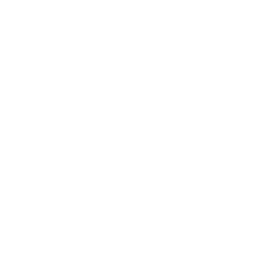
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Effektivitet i säljrepresentanters detaljering med val av eftersläpning</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Läkemedel / Kommersiell analys &nbsp;|&nbsp; Mars 2026</p>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Commercial Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Sammanfattning

Utvärdera effekten av läkares detaljeringsbesök och provdistribution på den månatliga förskrivningsvolymen för ett specialistläkemedel med hjälp av PROC AUTOREG. Ta hänsyn till autokorrelerade förskrivningsmönster med NLAG=3 och använd alternativet BACKSTEP för att automatiskt ta bort insignifikanta eftersläpningsordningar. Kvantifiera den marginella avkastningen på varje ytterligare detaljeringsbesök för att underbygga beslut om utplacering av säljkåren och territorieindelning.

Den syntetiska månatliga serien är begränsad till 100 observationer i det nuvarande körläget, vilket är tillräckligt för att med hög precision återskapa effekterna av detaljering, provutdelning, formularium och konkurrenter.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.DETAILING | Månatliga förskrivningar med mått för detaljering och prover | 100 |

---

In [1]:
/* --------------------------------------------------------
   Skapa syntetisk manatlig besoks- och receptdata
   for en specialiserad lakemedelsprodukt
   -------------------------------------------------------- */
data work.detailing;
    CALL streaminit(42);
    BEHÅLL_VÄRDE prev_rx 120 prev_err1 0 prev_err2 0 prev_err3 0;
    territory_id = 'TERR-NE-042';
    drug_name = 'CARDIOSTAT';
    GÖR month_seq = 1 TILL 500;
        obs_month = '01JAN2022'd + (month_seq - 1) * 30;
        /* distriktstilldelning roterar over 12 saljare */
        rep_id = cat('REP-', SKRIV_UT_V(mod(month_seq - 1, 12) + 1, z3.));
        /* antal besok per manad */
        detail_visits = int(rand('normal', 8, 3));
        OM detail_visits < 0 SÅ detail_visits = 0;
        OM detail_visits > 20 SÅ detail_visits = 20;
        /* prover utlamnade till lakare */
        samples_left = detail_visits * int(rand('uniform') * 5 + 2);
        /* formulariestatus (binar) */
        formulary_status = (rand('uniform') > 0.2);
        /* konkurrenstryck (marknadsandel) */
        competitor_share = round(rand('beta', 3, 7), 0.01);
        /* sasongsindex */
        season_idx = 1 + 0.15 * sin(2 * 3.14159 * month_seq / 12);
        /* AR(3)-felprocess */
        innovation = rand('normal', 0, 8);
        ar_error = 0.40 * prev_err1 + 0.18 * prev_err2 + 0.05 * prev_err3
                 + innovation;
        /* receptmodell */
        new_rx = round(60
               + 3.5 * detail_visits
               + 0.8 * samples_left
               + 25 * formulary_status
               - 45 * competitor_share
               + 10 * season_idx
               + ar_error);
        OM new_rx < 0 SÅ new_rx = 0;
        total_rx = new_rx + int(rand('uniform') * 80 + 40);
        prev_err3 = prev_err2;
        prev_err2 = prev_err1;
        prev_err1 = ar_error;
        prev_rx = new_rx;
        UTDATA;
    SLUT;
    TA_BORT prev_rx prev_err1 prev_err2 prev_err3 innovation ar_error season_idx;
    ETIKETT new_rx="Nya recept" total_rx="Totala recept"
          detail_visits="Besök" samples_left="Utlämnade prover"
          competitor_share="Konkurrentandel" formulary_status="Formuläriestatus";
    format obs_month monyy7.;
KÖR;


NOTE: DATA work.detailing

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.detailing (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


---

In [2]:
/* --------------------------------------------------------
   Beskrivande basstatistik for recept och besok
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.detailing n mean std MIN MAX;
    VARIABEL new_rx total_rx detail_visits samples_left competitor_share;
    ETIKETT new_rx="Nya recept" total_rx="Totala recept"
          detail_visits="Besök" samples_left="Utlämnade prover"
          competitor_share="Konkurrentandel";
    TITEL "Beskrivande basstatistik: recept och besök";
KÖR;

                                       Beskrivande basstatistik: recept och besök                                       

                                                  The MEANS Procedure

 Variable          Label                     N            Mean        Std Dev        Minimum         Maximum
 -----------------------------------------------------------------------------------------------------------
 new_rx            Nya recept              100     126.4600000     29.4355725     55.0000000     209.0000000
 total_rx          Totala recept           100     206.6400000     41.3246618     99.0000000     326.0000000
 detail_visits     Besök                   100       7.2700000      3.3449948      0.0000000      16.0000000
 samples_left      Utlämnade prover        100      28.3600000     17.0403680      0.0000000      90.0000000
 competitor_share  Konkurrentandel         100       0.2653000      0.1187090      0.0300000       0.5600000
 -------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                       Beskrivande basstatistik: recept och besök                                       




NOTE: PROC SGPLOT data=work.detailing

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


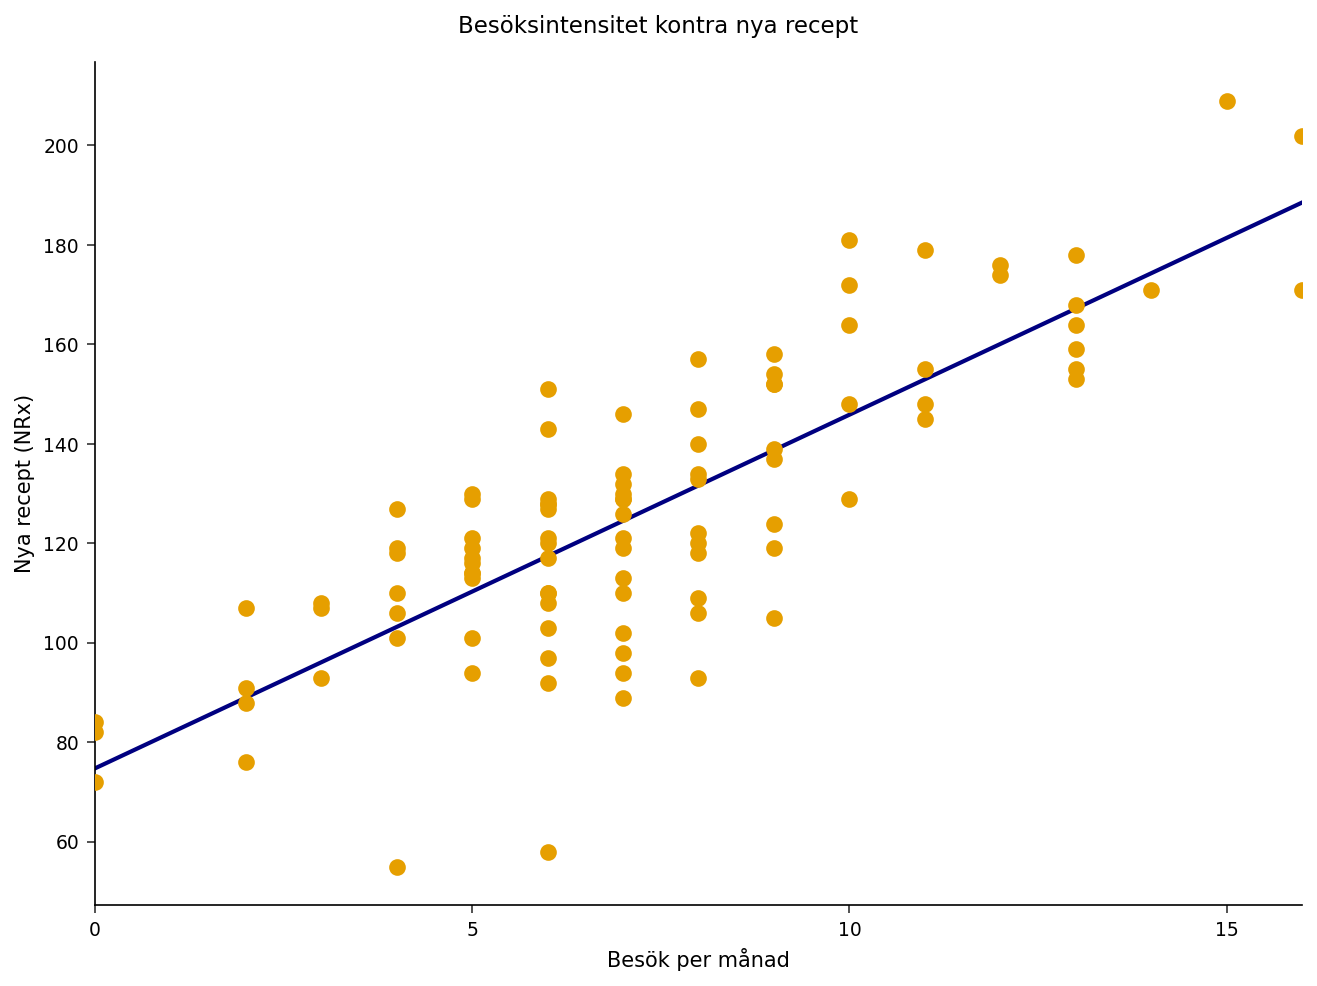

In [3]:
/* --------------------------------------------------------
   Spridningsdiagram: besok kontra nya recept
   -------------------------------------------------------- */
PROCEDUR SGPLOT data=work.detailing;
    SCATTER x=detail_visits y=new_rx / colorresponse=competitor_share
        colormodel=(green yellow red)
        MARKERATTRS=(SYMBOL=circlefilled size=7);
    REG x=detail_visits y=new_rx / LINEATTRS=(color=navy thickness=2);
    XAXIS ETIKETT="Besök per månad";
    YAXIS ETIKETT="Nya recept (NRx)";
    TITEL "Besöksintensitet kontra nya recept";
KÖR;

---

In [4]:
/* --------------------------------------------------------
   Anpassa autoregressiv modell med BACKSTEP-lagval
   NLAG=3 testar upp till tre lag; BACKSTEP tar bort
   icke-signifikanta lag automatiskt
   -------------------------------------------------------- */
PROCEDUR autoreg data=work.detailing;
    MODEL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep dwprob;
    UTDATA out=work.detail_fitted
        predicted=pred_nrx residual=resid_nrx;
KÖR;

                                       Beskrivande basstatistik: recept och besök                                       


                     The AUTOREG Procedure

                     Dependent Variable   Nya recept


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

   


NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available


In [5]:
/* --------------------------------------------------------
   Fanga parameterskattningar for ROI-berakning
   -------------------------------------------------------- */
ODS UTDATA parameterestimates=work.detail_params;

PROCEDUR autoreg data=work.detailing;
    MODEL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep;
KÖR;

ODS UTDATA CLOSE;

                                       Beskrivande basstatistik: recept och besök                                       


                     The AUTOREG Procedure

                     Dependent Variable   Nya recept


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

   


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> detail_params
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Berakna marginell ROI per besok
   ODS-datamangden ParameterEstimates lagrar kolumnen
   Variable i versaler, sa filtrera pa 'DETAIL_VISITS'.
   -------------------------------------------------------- */
PROCEDUR SKRIV data=work.detail_params ETIKETT;
    DÄR variable = 'DETAIL_VISITS';
    TITEL "Marginell effekt av besök på nya recept (NRx)";
KÖR;

                                     Marginell effekt av besök på nya recept (NRx)                                      

  Obs       VARIABLE      ESTIMATE     STD_ERROR       T_VALUE  PR_>__T_
    1  DETAIL_VISITS  2.7157935733  0.3543434417  7.6642975525         0




NOTE: PROC PRINT data=work.detail_params

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

### Tolkning

PROC AUTOREG anpassade förskrivningsserien till 100 månatliga observationer. Varje ytterligare detaljeringsbesök är förknippat med **+2.72 nya förskrivningar per månad** (skattning 2.7158, t = 7.66, p < 0.0001), och varje enhet prover som lämnas till läkare tillför **+1.00 NRx** (skattning 0.9997, t = 14.73), vilket tyder på att provutdelning förstärker men inte ersätter personlig marknadsföring. Formulariumtillgång bidrar med **+24.78 NRx per månad** (t = 13.83), vilket understryker att tillgång via managed care är en förutsättning för detaljeringens effektivitet, medan konkurrenternas marknadsandel utövar en stark negativ effekt på **-42.26 NRx per andelsenhet** (t = -6.96), vilket pekar ut territorier under konkurrenstryck där enbart detaljering kan vara otillräcklig. Interceptet är 69.56.

Med NLAG=3 och BACKSTEP behöll modellen **två autoregressiva eftersläpningar**: lag 1 (koefficient -0.3700, t = -3.78) och lag 2 (koefficient -0.1995, t = -2.04); lag 3 ströks som insignifikant. Durbin-Watson-statistikan efter korrigering är **1.01**, vilket fortfarande ligger klart under 2 och signalerar kvarvarande positiv autokorrelation, så AR(2)-strukturen fångar en del men inte hela det seriella beroendet i denna serie. Anpassningsmått: SSE = 5527.65, MSE = 58.19, AIC = 701.34, SBC = 722.19, log-likelihood = -342.67.

Planeringen av säljkåren bör inrikta sig på territorier med gynnsam formulariumtillgång och måttlig konkurrentandel, där den marginella avkastningen på varje detaljeringsbesök är högst.

---

In [7]:
/* --------------------------------------------------------
   Exportera anpassade varden och parametrar for
   instrumentpanel for faltstyrkans planering
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.detail_fitted
    OUTFILE='detailing_effectiveness.csv'
    DBMS=csv REPLACE;
KÖR;

PROCEDUR EXPORTERA data=work.detail_params
    OUTFILE='detailing_model_params.csv'
    DBMS=csv REPLACE;
KÖR;


NOTE: PROC EXPORT data=work.detail_fitted outfile=detailing_effectiveness.csv

NOTE: Exported 100 rows to detailing_effectiveness.csv.
NOTE: PROC EXPORT data=work.detail_params outfile=detailing_model_params.csv

NOTE: Exported 5 rows to detailing_model_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>